In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier, RandomForestClassifier
from xgboost import XGBClassifier

mpl.rcParams['image.cmap'] = "winter"
plt.rcParams['font.size'] = 13

# ------ dataset params ------
N = 5000
L = 4
B = 100
N_train = int(0.75 * N)

In [3]:
# ------ label function ------
def f(x):
    return np.heaviside(np.sin(np.pi * (x[1] + 2*x[0]) * (2*x[1] - x[0]) / 2000), 0)

# ------ function that generate a different dataset for every seed -----
def generate_dataset(seed):
    np.random.seed(seed)
    x = (np.random.random((N, L)) - 0.5) * B
    y = np.zeros(N).astype(int)

    for i in range(N):
        y[i] = f(x[i, :2])

    # ------ shuffle for reducing variability ------
    idx = np.random.permutation(N)
    x, y = x[idx], y[idx]

    return x, y

In [4]:
# ------ models definition ------
models = {
    "AdaBoost": AdaBoostClassifier(
        n_estimators=200,
        learning_rate=0.1,
        random_state=12345
    ),

    "GradientBoosting": GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=6
    ),

    "XGBoost": XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        subsample=1.0,
        random_state=12345,
        verbosity=0
    ),

    "RandomForest": RandomForestClassifier(
        n_estimators=200,
        max_depth=6,
        random_state=12345
    )
}

In [5]:

n_runs = 20 # number of runs

results = {name: [] for name in models.keys()} # list of validation accuracyes for every model

# ------ generation and split of the datasets, evaluation of the accuray for every model ------
for seed in range(n_runs):
    x, y = generate_dataset(seed)

    x_train, x_test = x[:N_train], x[N_train:]
    y_train, y_test = y[:N_train], y[N_train:]

    for name, model in models.items():
        model.fit(x_train, y_train)
        acc = model.score(x_test, y_test)
        results[name].append(acc)

In [6]:
# ------ evaluation of the mean accuracy and standard deviation ------
names = []
means = []
stds = []

print("Results (mean ± std):\n")

for name in models.keys():
    accs = np.array(results[name])
    mean = accs.mean()
    std = accs.std()

    names.append(name)
    means.append(mean)
    stds.append(std)

    print(f"{name:20s}: {mean:.3f} ± {std:.3f}")

Results (mean ± std):

AdaBoost            : 0.569 ± 0.019
GradientBoosting    : 0.929 ± 0.009
XGBoost             : 0.928 ± 0.008
RandomForest        : 0.797 ± 0.015


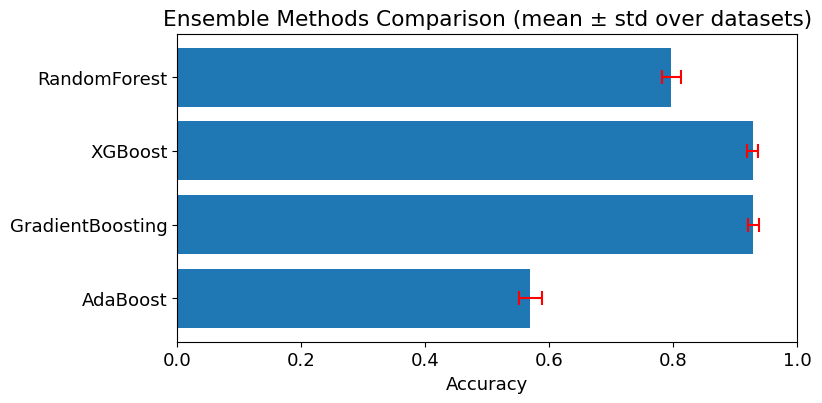

In [48]:
# ------ bar plot ------
plt.figure(figsize=(8,4))

plt.barh(names, means, xerr=stds, error_kw=dict(
        ecolor="red",     # colore error bar
        elinewidth=1.5,   # spessore linea
        capsize=5,        # lunghezza dei trattini verticali
        capthick=1.5      # spessore dei cap
    ))
plt.xlabel("Accuracy")
plt.title("Ensemble Methods Comparison (mean ± std over datasets)")
plt.xlim(0, 1)

plt.show()